In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D,Flatten,Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
train_datagene = ImageDataGenerator(rescale = 1./255,
shear_range = 0.2, zoom_range = 0.2, horizontal_flip = True)

test_datagene = ImageDataGenerator(rescale = 1./255)
training_set = train_datagene.flow_from_directory(
    'dataset/train',
    target_size = (64,64),
    batch_size = 32,
    class_mode = 'binary'
)
test_set = test_datagene.flow_from_directory(
    'dataset/test',
    target_size = (64,64),
    batch_size = 32,
    class_mode = 'binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [11]:
model = Sequential()
model.add(Conv2D(32,(3,3),input_shape = (64,64,3),activation='relu'))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(units=128,activation='relu'))
model.add(Dense(units=1,activation= 'sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
import matplotlib.pyplot as plt
print("Let's play something it is going to take some time")
checkpoint = ModelCheckpoint('pneumonia_best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max',verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
history = model.fit(
    training_set,
    validation_data = test_set,
    epochs = 10,
    callbacks=[checkpoint, early_stop]
)
model.save('pneumonia_model.h5')
print("Model saved successfully")

Let's play something it is going to take some time
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.7574 - loss: 0.5315
Epoch 1: val_accuracy improved from None to 0.84615, saving model to pneumonia_best_model.h5



Epoch 1: finished saving model to pneumonia_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 665ms/step - accuracy: 0.8083 - loss: 0.4305 - val_accuracy: 0.8462 - val_loss: 0.3717
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.8812 - loss: 0.2719
Epoch 2: val_accuracy improved from 0.84615 to 0.85417, saving model to pneumonia_best_model.h5



Epoch 2: finished saving model to pneumonia_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 703ms/step - accuracy: 0.8907 - loss: 0.2653 - val_accuracy: 0.8542 - val_loss: 0.3275
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.9059 - loss: 0.2329
Epoch 3: val_accuracy improved from 0.85417 to 0.87340, saving model to pneumonia_best_model.h5



Epoch 3: finished saving model to pneumonia_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 145s 718ms/step - accuracy: 0.9080 - loss: 0.2283 - val_accuracy: 0.8734 - val_loss: 0.2905
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.9209 - loss: 0.1980
Epoch 4: val_accuracy improved from 0.87340 to 0.90545, saving model to pneumonia_best_model.h5



Epoch 4: finished saving model to pneumonia_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 701ms/step - accuracy: 0.9245 - loss: 0.1898 - val_accuracy: 0.9054 - val_loss: 0.2676
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.9243 - loss: 0.1798
Epoch 5: val_accuracy did not improve from 0.90545
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 705ms/step - accuracy: 0.9248 - loss: 0.1793 - val_accuracy: 0.8974 - val_loss: 0.2514
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.9287 - loss: 0.1771
Epoch 6: val_accuracy did not improve from 0.90545
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 649ms/step - accuracy: 0.9291 - loss: 0.1713 - val_accuracy: 0.8926 - val_loss: 0.2651
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.9370 - loss: 0.1604
Epoch 7: val_accuracy improved from 0.90545 to 0.91827, saving model to pneumonia_best_model.h5



Epoch 7: finished saving model to pneumonia_best_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 378ms/step - accuracy: 0.9398 - loss: 0.1526 - val_accuracy: 0.9183 - val_loss: 0.2215
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9435 - loss: 0.1531
Epoch 8: val_accuracy did not improve from 0.91827
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 361ms/step - accuracy: 0.9388 - loss: 0.1582 - val_accuracy: 0.9071 - val_loss: 0.2620
Epoch 9/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9469 - loss: 0.1387
Epoch 9: val_accuracy did not improve from 0.91827
163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 383ms/step - accuracy: 0.9411 - loss: 0.1465 - val_accuracy: 0.9183 - val_loss: 0.2287
Epoch 10/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9489 - loss: 0.1385
Epoch 10: val_accuracy did not improve from 0.91827
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 454ms/step - accuracy: 0.9463 - loss: 0.1411 - val_accuracy: 0.8926 - val_loss: 0.3462


Model saved successfully


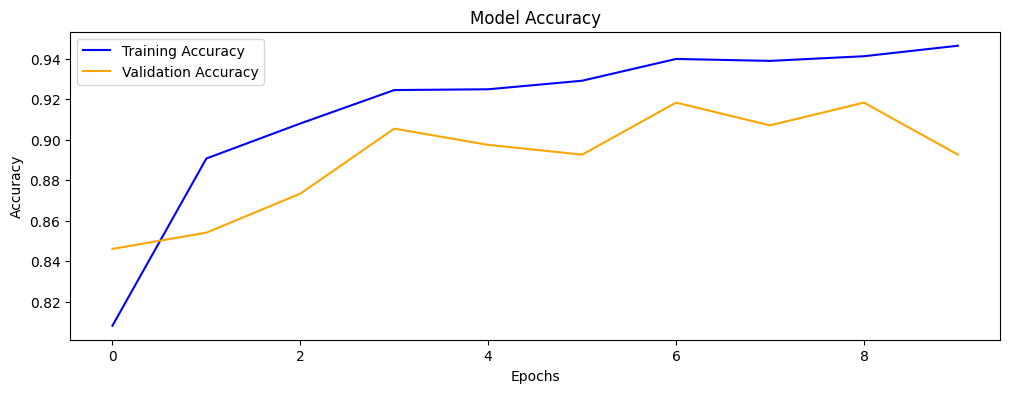

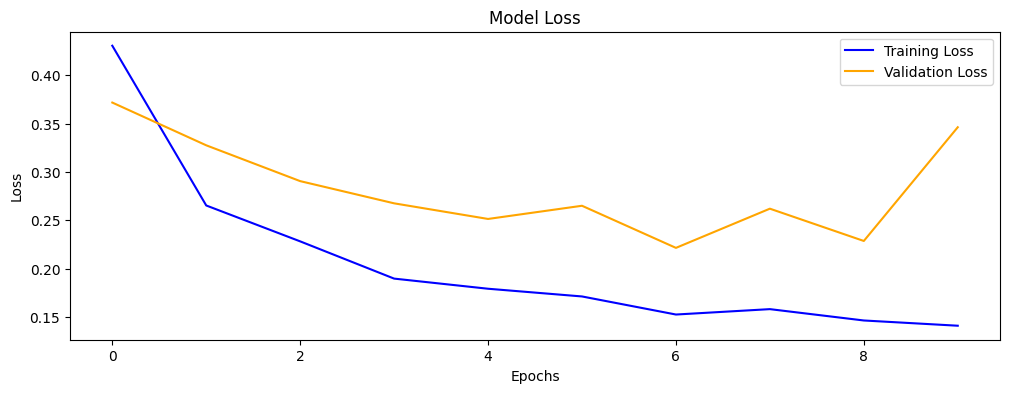

In [13]:
plt.figure(figsize=(12,4))
plt.plot(history.history['accuracy'],label='Training Accuracy',color='blue')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy',color='orange')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(history.history['loss'],label='Training Loss',color='blue')
plt.plot(history.history['val_loss'],label='Validation Loss',color='orange')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()